### mask out the boundary area

In [1]:
import rasterio
from rasterio.windows import Window
from rasterio.windows import transform as win_transform

in_path  = r"D:\wenqu\mosaic\PCA\site2c_pca_clean.tiff"
out_path = r"D:\wenqu\mosaic\PCA\PCA_boundary_remove\site2c_pca_cropped.tif"

pad = 50  # pixels to remove from each edge

with rasterio.open(in_path) as src:
    # New size after trimming 10 px from left+right and top+bottom
    new_width  = src.width  - 2*pad
    new_height = src.height - 2*pad
    if new_width <= 0 or new_height <= 0:
        raise ValueError("Image is too small to trim 10 pixels on each side.")

    # Define the crop window (col_off, row_off, width, height)
    win = Window(pad, p ad, new_width, new_height)

    # Read all bands inside this window
    data = src.read(window=win)  # shape: (count, new_height, new_width)

    # Update profile
    profile = src.profile.copy()
    profile.update({
        "width": new_width,
        "height": new_height,
        "transform": win_transform(win, src.transform)
    })

    # Write out
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(data)

print("Done:", out_path)


Done: D:\wenqu\mosaic\PCA\PCA_boundary_remove\site2c_pca_cropped.tif


In [2]:
import numpy as np
import rasterio
from skimage.morphology import erosion, square
from scipy.ndimage import binary_fill_holes, distance_transform_edt  # <-- add this
# ---- CONFIG ----
tif_in       = r"D:\wenqu\mosaic\PCA\site2a_pca_clean.tiff"
tif_out      = r'D:\wenqu\mosaic\PCA\fixed_width\site2a_pca_boundary.tif'
edge_pixels  = 50  # inward erosion width in pixels (tune this)
nodata_value = np.nan 
# ----------------

with rasterio.open(tif_in) as src:
    arr = src.read().astype(np.float32)   # (C, H, W) -> float so we can write NaNs
    profile = src.profile.copy()
    H, W = src.height, src.width

# 1) Scene footprint (True where ANY band is finite)
footprint = np.any(np.isfinite(arr), axis=0)          # (H, W)

# 2) Fill interior holes so trimming only follows the OUTER boundary
filled = binary_fill_holes(footprint)                 # (H, W), holes removed

# 3) Distance (in pixels) from the outer boundary inward
#    (distance inside 'filled' to nearest 0 outside)
dist = distance_transform_edt(filled.astype(np.uint8))

# 4) Keep only pixels farther than 'edge_pixels' from the outer boundary,
#    but never add pixels that were originally invalid.
keep = (dist > edge_pixels) & footprint               # (H, W)

# 5) Apply mask to ALL bands
if np.isnan(nodata_value):
    arr[:, ~keep] = np.nan
    profile.update(dtype="float32", nodata=np.nan)
else:
    arr[:, ~keep] = float(nodata_value)
    profile.update(dtype="float32", nodata=float(nodata_value))

# 6) Write masked GeoTIFF (georeferencing preserved)
with rasterio.open(tif_out, "w", **profile) as dst:
    dst.write(arr)

print(f"Saved: {tif_out}")


Saved: D:\wenqu\mosaic\PCA\fixed_width\site2a_pca_boundary.tif


In [1]:
import numpy as np
import rasterio
from skimage.segmentation import quickshift
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
# OPTIONAL vectorization
# pip install geopandas fiona  (or) pip install pyogrio
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes



In [2]:
tif_path = r'D:\wenqu\mosaic\PCA\fixed_width\site2c_pca_boundary.tif'

# 1) Read 3 bands
with rasterio.open(tif_path) as src:
    img = src.read([1, 2, 3]).astype(np.float32)   # (3,H,W)
H, W = img.shape[1:]

# 2) Valid mask: True where all bands are finite (not NaN)
valid = np.all(np.isfinite(img), axis=0)

In [3]:
# 3) Scale each band robustly to [0,1]
img_s = img.copy()
for b in range(3):
    v = img[b][valid]
    if v.size:
        lo, hi = np.nanpercentile(v, [2, 98])
        if hi > lo:
            img_s[b] = np.clip((img[b] - lo) / (hi - lo), 0, 1)
        else:
            img_s[b] = 0
    else:
        img_s[b] = 0

In [4]:
# # 4) Downsample for speed/coarseness
# down_factor = 10  
# if down_factor > 1:
#     img_ds   = img_s[:, ::down_factor, ::down_factor]
#     valid_ds = valid[::down_factor, ::down_factor]
# else:
#     img_ds, valid_ds = img_s, valid


In [5]:
# 5) Quickshift on (h,w,c)
im_in = np.moveaxis(img_s, 0, -1)
segments_ds = quickshift(
    im_in,
    kernel_size=5,
    max_dist=10,
    ratio=0.5,
    sigma=2,
    convert2lab=False
)

In [7]:
# 6) Upsample labels back to original size
# segments = np.repeat(np.repeat(segments_ds, down_factor, 0), down_factor, 1)
segments = segments_ds[:H, :W].astype(np.int32)
segments[~valid] = -1

Number of segments (excluding background): 658896


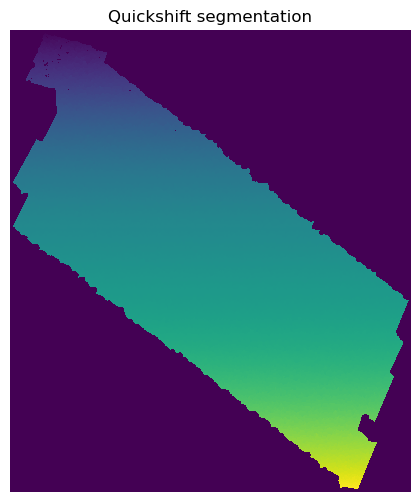

In [8]:
# 7) Report & visualize
print("Number of segments (excluding background):", len(np.unique(segments[segments != -1])))

plt.figure(figsize=(6,6))
plt.imshow(segments, interpolation='nearest')
plt.title("Quickshift segmentation")
plt.axis('off')
plt.show()

In [9]:
mask = (segments != -1)

In [10]:
with rasterio.open(tif_path) as src:
    band1 = src.read(1).astype(np.float32)  # (H, W)
    transform = src.transform
    crs = src.crs
    profile = src.profile

In [11]:
records = []
for geom, seg_id in shapes(segments.astype(np.int32), mask=mask, transform=transform):
    records.append({"geometry": shape(geom), "segment_id": int(seg_id)})

gdf = gpd.GeoDataFrame(records, crs=crs)

In [12]:
# Save as ESRI Shapefile
shp_out = r'D:\wenqu\mosaic\PCA\shapefile\site2c_segmentation_k5_d10.shp'
gdf.to_file(shp_out, driver="ESRI Shapefile")
print("Wrote shapefile:", shp_out, " | features:", len(gdf))

Wrote shapefile: D:\wenqu\mosaic\PCA\shapefile\site2c_segmentation_k5_d10.shp  | features: 659053
